In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

In [2]:
from analysis.color_segmentation import RGBBlobDetector, inspect_blobs
detector = RGBBlobDetector()

### Inspect the blobs
- Press "q" to end
- Note the blob number of the blobs you want to mark later

In [3]:
path = ".cache/_MG_7359.JPG"
frame = cv2.imread(path)
masks = detector.segment_colors(frame)

# INSPECTING BLOBS:
color = "blue"
cleaned = detector.clean_mask(masks[color])
blobs = detector.extract_blob_features(cleaned)
blobs_w_features = detector.add_local_contrast_features(frame, blobs, color, ring_size=8, debug=True)
print(f"{len(blobs_w_features)} {color} blobs")
# inspect_blobs(frame, blobs, window_name=f"{color.upper()} Blob Inspector")
cv2.destroyAllWindows()

blobs_1 = blobs_w_features.copy()

Local contrast [blue]: 3310/3310 blobs (100.0%)
3310 blue blobs


In [ ]:
path = ".cache/frame_20261004_190911_130956.png"
frame = cv2.imread(path)
masks = detector.segment_colors(frame)

# INSPECTING BLOBS:
color = "red"
cleaned = detector.clean_mask(masks[color])
blobs = detector.extract_blob_features(cleaned)
blobs_w_features = detector.add_local_contrast_features(frame, blobs, color, debug=True)
print(f"{len(blobs_w_features)} {color} blobs")
# inspect_blobs(frame, blobs, window_name=f"{color.upper()} Blob Inspector")
cv2.destroyAllWindows()

blobs_2 = blobs_w_features.copy()

Local contrast [red]: 2529/2529 blobs (100.0%)
2529 red blobs


In [5]:
sample_1 = {
    "name": "_MG_7359",
    "sample": "yellow",
    "blobs": blobs_1,
    "blob_nrs": [180, 186, 624, 640, 1721, 1617, 1721, 2066, 2027, 1959, 1794, 2202, 2198]
}

sample_2 = {
    "name": "frame_20261004_190911_130956",
    "sample": "red",
    "blobs": blobs_2,
    "blob_nrs": [36,37,42,44,39,41]
}

all_samples_OI = [sample_1, sample_2]

In [7]:
def print_feature_stats(values, feature_name, indent="  "):
    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        print(f"{indent}{feature_name}: no values")
        return

    print(
        f"{indent}{feature_name}: "
        f"min={np.min(values):.4f} | "
        f"p10={np.percentile(values, 10):.4f} | "
        f"p25={np.percentile(values, 25):.4f} | "
        f"p50={np.percentile(values, 50):.4f} | "
        f"p75={np.percentile(values, 75):.4f} | "
        f"p90={np.percentile(values, 90):.4f} | "
        f"max={np.max(values):.4f}"
    )


def plot_blob_scatter(samples, x_feature, y_feature):
    plt.figure(figsize=(9, 7))

    other_x, other_y = [], []
    combined_x, combined_y = [], []

    print(f"\n{'=' * 70}")
    print(f"--- Plotting {x_feature} vs {y_feature} ---")
    print(f"Samples: {len(samples)}")

    # Validate + collect other blobs
    for sample in samples:
        name = sample["name"]
        blobs = sample["blobs"]
        blob_nrs = sample["blob_nrs"]
        selected = set(blob_nrs)

        invalid = [i for i in selected if i < 0 or i >= len(blobs)]
        valid = [i for i in selected if 0 <= i < len(blobs)]

        print(
            f"\n{name}: "
            f"{len(blobs)} blobs | "
            f"{len(valid)} selected | "
            f"color={sample['sample']}"
        )

        if invalid:
            print(f"  WARNING: Invalid blob indices: {invalid}")

        # Selected values for this sample
        x = [blobs[i][x_feature] for i in valid]
        y = [blobs[i][y_feature] for i in valid]

        print_feature_stats(x, x_feature)
        print_feature_stats(y, y_feature)

        combined_x.extend(x)
        combined_y.extend(y)

        # Non-selected blobs
        for i, blob in enumerate(blobs):
            if i not in selected:
                other_x.append(blob[x_feature])
                other_y.append(blob[y_feature])

    print(f"\n--- Combined selected blobs ---")
    print(f"Total selected blobs: {len(combined_x)}")

    print_feature_stats(combined_x, x_feature)
    print_feature_stats(combined_y, y_feature)

    print(f"\n--- Other blobs ---")
    print(f"Total other blobs: {len(other_x)}")

    print_feature_stats(other_x, x_feature)
    print_feature_stats(other_y, y_feature)

    # All non-selected blobs
    plt.scatter(
        other_x, other_y,
        s=20,
        c="blue",
        alpha=0.4,
        label="Other blobs"
    )

    # Selected blobs per sample
    for sample in samples:
        name = sample["name"]
        blobs = sample["blobs"]
        selected = set(sample["blob_nrs"])

        valid = [
            i for i in selected
            if 0 <= i < len(blobs)
        ]

        x = [blobs[i][x_feature] for i in valid]
        y = [blobs[i][y_feature] for i in valid]

        plt.scatter(
            x, y,
            s=80,
            c=sample["sample"],
            edgecolors="black",
            linewidths=1,
            label=name
        )

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{y_feature} vs {x_feature}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


--- Plotting circularity vs solidity ---
Samples: 2

_MG_7359: 3106 blobs | 12 selected | color=yellow
  circularity: min=0.0550 | p10=0.1708 | p25=0.2278 | p50=0.2970 | p75=0.3398 | p90=0.3526 | max=0.4015
  solidity: min=0.3033 | p10=0.5520 | p25=0.5635 | p50=0.6638 | p75=0.7659 | p90=0.8334 | max=0.8547

frame_20261004_190911_130956: 166 blobs | 6 selected | color=red
  circularity: min=0.2647 | p10=0.2672 | p25=0.2700 | p50=0.3207 | p75=0.4574 | p90=0.5644 | max=0.6423
  solidity: min=0.5926 | p10=0.6048 | p25=0.6244 | p50=0.7083 | p75=0.7952 | p90=0.8607 | max=0.9180

--- Combined selected blobs ---
Total selected blobs: 18
  circularity: min=0.0550 | p10=0.1913 | p25=0.2464 | p50=0.2970 | p75=0.3506 | p90=0.4270 | max=0.6423
  solidity: min=0.3033 | p10=0.5533 | p25=0.5987 | p50=0.6638 | p75=0.7828 | p90=0.8434 | max=0.9180

--- Other blobs ---
Total other blobs: 3254
  circularity: min=0.0081 | p10=0.1072 | p25=0.1850 | p50=0.3215 | p75=0.5359 | p90=0.6430 | max=0.9433
  solidi

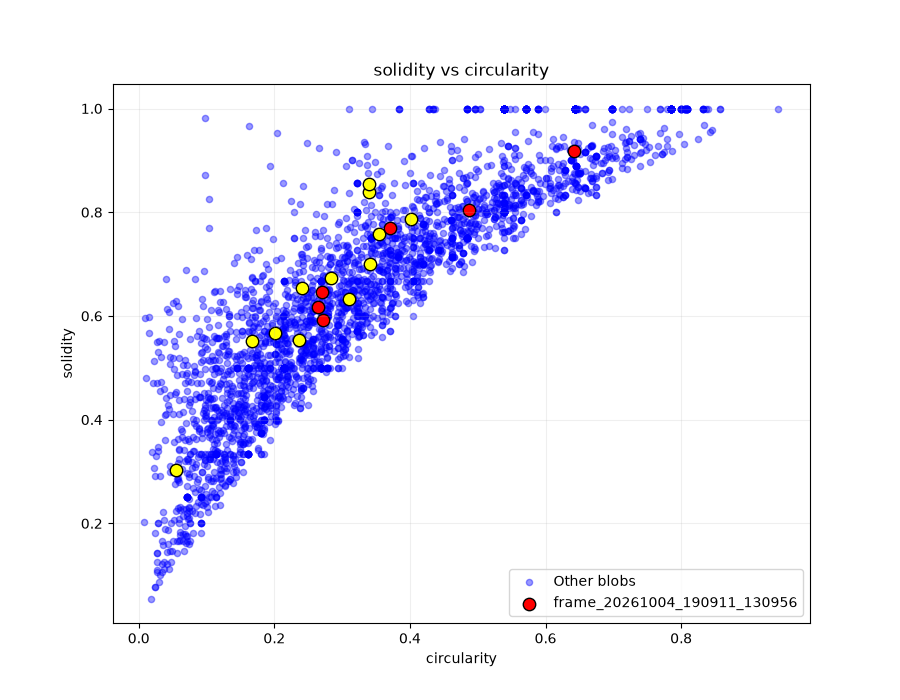


--- Plotting circularity vs aspect_ratio ---
Samples: 2

_MG_7359: 3106 blobs | 12 selected | color=yellow
  circularity: min=0.0550 | p10=0.1708 | p25=0.2278 | p50=0.2970 | p75=0.3398 | p90=0.3526 | max=0.4015
  aspect_ratio: min=0.3125 | p10=0.3276 | p25=0.3680 | p50=0.5771 | p75=0.6932 | p90=0.8442 | max=1.2500

frame_20261004_190911_130956: 166 blobs | 6 selected | color=red
  circularity: min=0.2647 | p10=0.2672 | p25=0.2700 | p50=0.3207 | p75=0.4574 | p90=0.5644 | max=0.6423
  aspect_ratio: min=0.6000 | p10=0.7359 | p25=0.8836 | p50=0.9872 | p75=1.6389 | p90=1.9167 | max=2.0000

--- Combined selected blobs ---
Total selected blobs: 18
  circularity: min=0.0550 | p10=0.1913 | p25=0.2464 | p50=0.2970 | p75=0.3506 | p90=0.4270 | max=0.6423
  aspect_ratio: min=0.3125 | p10=0.3285 | p25=0.5083 | p50=0.6397 | p75=0.9071 | p90=1.4250 | max=2.0000

--- Other blobs ---
Total other blobs: 3254
  circularity: min=0.0081 | p10=0.1072 | p25=0.1850 | p50=0.3215 | p75=0.5359 | p90=0.6430 | max

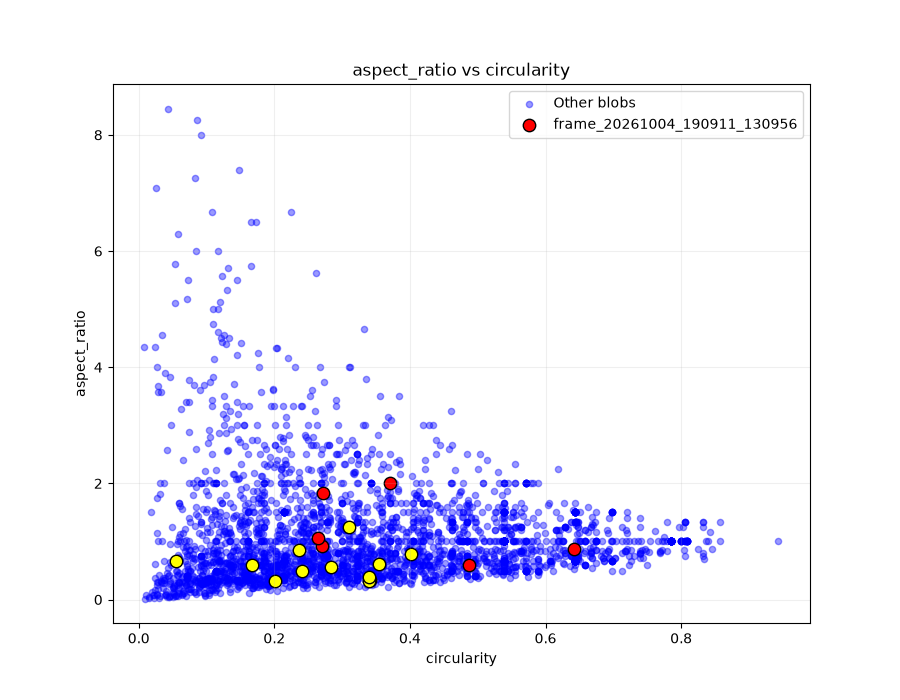


--- Plotting circularity vs extent ---
Samples: 2

_MG_7359: 3106 blobs | 12 selected | color=yellow
  circularity: min=0.0550 | p10=0.1708 | p25=0.2278 | p50=0.2970 | p75=0.3398 | p90=0.3526 | max=0.4015
  extent: min=0.2022 | p10=0.2679 | p25=0.3305 | p50=0.3757 | p75=0.4407 | p90=0.4702 | max=0.5218

frame_20261004_190911_130956: 166 blobs | 6 selected | color=red
  circularity: min=0.2647 | p10=0.2672 | p25=0.2700 | p50=0.3207 | p75=0.4574 | p90=0.5644 | max=0.6423
  extent: min=0.2798 | p10=0.2815 | p25=0.3037 | p50=0.4026 | p75=0.4678 | p90=0.5466 | max=0.6161

--- Combined selected blobs ---
Total selected blobs: 18
  circularity: min=0.0550 | p10=0.1913 | p25=0.2464 | p50=0.2970 | p75=0.3506 | p90=0.4270 | max=0.6423
  extent: min=0.2022 | p10=0.2750 | p25=0.3129 | p50=0.3757 | p75=0.4443 | p90=0.4905 | max=0.6161

--- Other blobs ---
Total other blobs: 3254
  circularity: min=0.0081 | p10=0.1072 | p25=0.1850 | p50=0.3215 | p75=0.5359 | p90=0.6430 | max=0.9433
  extent: min=0.

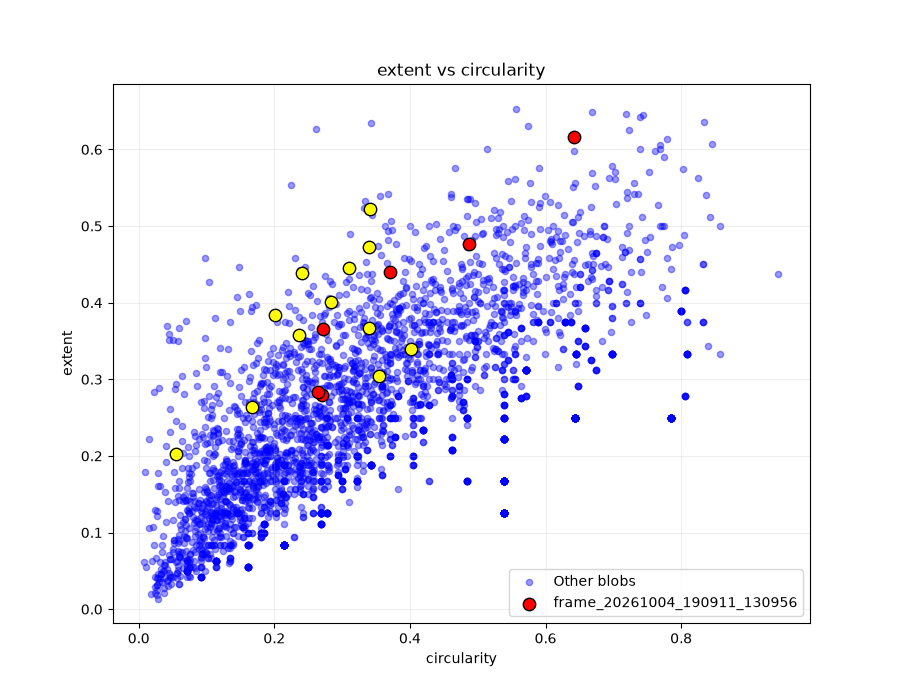


--- Plotting area vs perimeter ---
Samples: 2

_MG_7359: 3106 blobs | 12 selected | color=yellow
  area: min=247.0000 | p10=336.3000 | p25=435.7500 | p50=612.0000 | p75=1044.0000 | p90=1564.2000 | max=1854.0000
  perimeter: min=95.5980 | p10=111.6313 | p25=155.4386 | p50=181.4386 | p75=238.6769 | p90=289.6640 | max=316.3503

frame_20261004_190911_130956: 166 blobs | 6 selected | color=red
  area: min=114.5000 | p10=143.5000 | p25=217.3750 | p50=368.7500 | p75=387.0000 | p90=602.2500 | max=817.0000
  perimeter: min=54.3848 | p10=65.4558 | p25=89.0018 | p50=127.2548 | p75=132.2505 | p90=134.6396 | max=135.6396

--- Combined selected blobs ---
Total selected blobs: 18
  area: min=114.5000 | p10=224.6500 | p25=357.7500 | p50=471.5000 | p75=793.2500 | p90=1322.4000 | max=1854.0000
  perimeter: min=54.3848 | p10=89.8767 | p25=126.8406 | p50=150.0244 | p75=189.7211 | p90=271.2376 | max=316.3503

--- Other blobs ---
Total other blobs: 3254
  area: min=0.5000 | p10=1.0000 | p25=3.0000 | p50=12

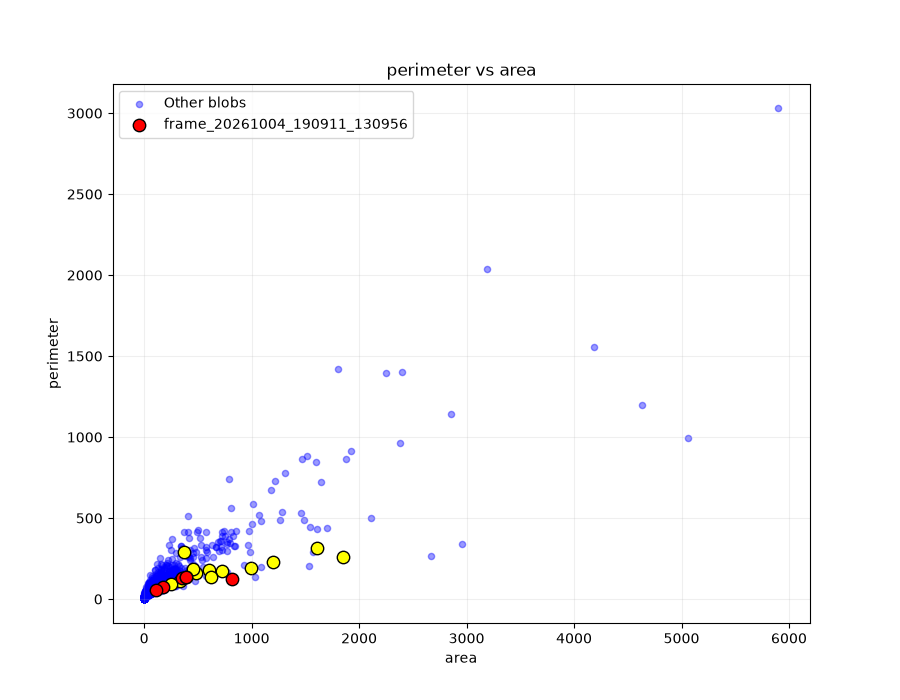

In [11]:
plot_blob_scatter(all_samples_OI, "circularity", "solidity")
plot_blob_scatter(all_samples_OI, "circularity", "aspect_ratio")
plot_blob_scatter(all_samples_OI, "circularity", "extent")
plot_blob_scatter(all_samples_OI, "area", "perimeter")


--- Plotting delta_v vs delta_dominance ---
Samples: 2

_MG_7359: 3310 blobs | 12 selected | color=yellow
  delta_v: min=-27.7297 | p10=-13.4089 | p25=-1.0396 | p50=7.5722 | p75=9.7110 | p90=12.8662 | max=16.2273
  delta_dominance: min=-7.9917 | p10=3.9508 | p25=4.8094 | p50=10.4700 | p75=14.0767 | p90=20.9575 | max=29.6707

frame_20261004_190911_130956: 2529 blobs | 6 selected | color=red
  delta_v: min=10.3766 | p10=12.2204 | p25=14.1004 | p50=16.0499 | p75=19.7954 | p90=20.4991 | max=20.5678
  delta_dominance: min=2.6613 | p10=2.8040 | p25=3.6404 | p50=6.1640 | p75=7.3912 | p90=8.6813 | max=9.7099

--- Combined selected blobs ---
Total selected blobs: 18
  delta_v: min=-27.7297 | p10=-7.4940 | p25=2.0867 | p50=9.7336 | p75=14.1728 | p90=18.6526 | max=20.5678
  delta_dominance: min=-7.9917 | p10=2.8611 | p25=4.3184 | p50=7.4617 | p75=12.9702 | p90=18.1083 | max=29.6707

--- Other blobs ---
Total other blobs: 5821
  delta_v: min=-76.1216 | p10=-16.1827 | p25=4.5184 | p50=14.2545 | p7

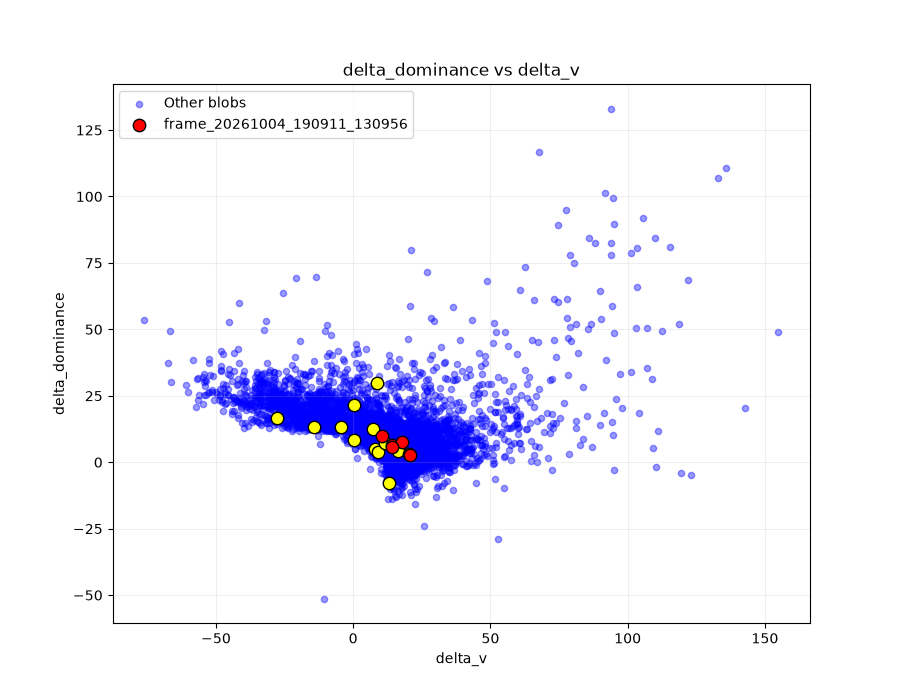

In [8]:
plot_blob_scatter(all_samples_OI, "delta_v", "delta_dominance")

### Show a specific frame form a video

In [16]:
from frame.FrameSource import VideoSource

def show_video_frame(video, frame_number, window_name="Video Frame"):
    frame = video.seek(frame_number)

    if frame is None:
        print(f"Could not read frame {frame_number}")
        return None

    print(
        f"Frame: {frame.frame_number} | "
        f"Time: {frame.timestamp:.2f}s"
    )

    display = frame.image.copy()

    cv2.putText(
        display,
        f"Frame {frame.frame_number} | {frame.timestamp:.2f}s",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 255, 255),
        3,
        cv2.LINE_AA
    )

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.imshow(window_name, display)
    cv2.resizeWindow(window_name, 1280, 720)

    print("S = save | Q = quit")

    while True:
        key = cv2.waitKey(0) & 0xFF

        if key == ord("s"):
            cv2.imwrite(
                f".cache/frame_{frame.frame_number}.png",
                frame.image
            )
            print(f"Saved frame {frame.frame_number}")

        elif key == ord("q"):
            break

    cv2.destroyWindow(window_name)

    return frame

In [21]:
path = r"C:\Users\light\Downloads\pf\PF_silent_disco\GX010808.MP4"

video = VideoSource(path)

show_video_frame(
    video,
    frame_number=5117
)

video.release()
cv2.destroyAllWindows()

Frame: 5117 | Time: 170.74s
S = save | Q = quit
